In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Loading

In [47]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_electron_loguniform/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 10000), full_load=False, detector_params=detector_params)

In [3]:
tracker_hits = batch.get_tracker_hits_df()
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
particles = batch.get_particles_df()
print(f"""
Unique events IDs in particles: {particles.event_id.unique()}
Length of particles: {len(particles)}
Length of tracker_hits: {len(tracker_hits)}
Length of calo_hits: {len(calo_hits)}
Length of calo_contributions: {len(calo_contributions)}
Events with non-empty calo_hits: {calo_hits.event_id.unique()}
""")

Augmenting particle hit counts with tracker hits

Unique events IDs in particles: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 2

In [55]:
calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_electron_loguniform/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 10000), full_load=False, detector_params=detector_params)

In [56]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
# print(f"""
# Unique events IDs in particles: {particles.event_id.unique()}
# Length of particles: {len(particles)}
# Length of calo_tracker_hits: {len(calo_tracker_hits)}
# Length of calo_truth_hits: {len(calo_truth_hits)}
# Length of calo_digi_contributions: {len(calo_digi_contributions)}
# Length of calo_digi_hits: {len(calo_digi_hits)}
# Events with non-empty calo_digi_hits: {calo_digi_hits.event_id.unique()}
# """)

Augmenting particle hit counts with tracker hits


: 

## Roadmap

1. What is the structure of calo digi file? A: Very similar to usual
2. Can we match truth calo cells to digitised cells? A: Yes, by cell ID
3. What is the residual on summed digitised energy vs generator energy? A: 
4. What is the digitised energy vs true cell energy?

In [7]:
print(f"Loaded {len(calo_digi_hits)} digitized calo hits")
print(f"\nColumns: {list(calo_digi_hits.columns)}")
print(f"\nDetectors: {calo_digi_hits['detector'].unique()}")
print(f"\nFirst few rows:")
print(calo_digi_hits.head())

# Verify all expected columns are present
expected_cols = ['cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 
                 'detector', 'r', 'R', 'phi', 'theta', 'eta', 'event_id']
missing_cols = set(expected_cols) - set(calo_digi_hits.columns)
if missing_cols:
    print(f"\nWARNING: Missing columns: {missing_cols}")
else:
    print(f"\n✓ All expected columns present")


Loaded 1253337 digitized calo hits

Columns: ['event_id', 'subentry', 'cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 'detector', 'r', 'R', 'phi', 'theta', 'eta']

Detectors: ['digiECalBarrelCollection' 'digiECalEndcapCollection'
 'digiHCalBarrelCollection' 'digiHCalEndcapCollection']

First few rows:
   event_id  subentry              cellID    energy  energy_error      time  \
0         5         0  125537663536476176  0.006445           0.0  0.179136   
1         6         0   73746340836491280  0.007339           0.0  3.072632   
2         6         1   74027815813267472  0.011765           0.0  3.070627   
3         6         2   74590770062049296  0.013411           0.0  3.082230   
4         6         3   75153728605667344  0.005911           0.0  3.099302   

             x            y            z    type                  detector  \
0 -1277.650024   209.100006  2269.500000   61010  digiECalBarrelCollection   
1  -834.739563  1007.839294  1331.099976  11101

In [8]:
calo_particles.iloc[1][["PDG", "vx", "vy", "vz", "px", "py", "pz", "energy"]]

PDG              11
vx              0.0
vy              0.0
vz              0.0
px        -0.271703
py          0.74433
pz       -13.002508
energy    13.026629
Name: 1, dtype: object

In [11]:
calo_digi_contributions

,event_id,subentry,energy,time,particle_id,detector
0,5,0,0.000172,8.788481,1,ECalBarrelCollection
1,6,0,0.000196,9.194777,1,ECalBarrelCollection
2,6,1,0.000314,9.216643,1,ECalBarrelCollection
3,6,2,0.000357,9.322108,1,ECalBarrelCollection
4,6,3,0.000158,9.408688,1,ECalBarrelCollection
...,...,...,...,...,...,...
32771885,996,53,0.000082,12.317056,161,HCalEndcapCollection
32771886,996,54,0.000008,936.715942,212,HCalEndcapCollection
32771887,996,55,0.000534,12.293084,222,HCalEndcapCollection
32771888,996,56,0.000146,12.296263,222,HCalEndcapCollection


In [12]:
calo_truth_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,5,0,125537663536476176,1.717500e-04,-1277.650024,209.100006,2269.500000,0,1,ECalBarrelCollection,1294.647583,2612.803467,2.979371,0.518412,1.327379
1,6,0,73746340836491280,1.955879e-04,-834.739563,1007.839294,1331.099976,0,1,ECalBarrelCollection,1308.636841,1866.643433,2.262525,0.776889,0.893459
2,6,1,74027815813267472,3.135537e-04,-838.310425,1011.410156,1336.199951,1,2,ECalBarrelCollection,1313.664673,1873.804932,2.262885,0.776894,0.893452
3,6,2,74590770062049296,3.574083e-04,-863.342041,1029.229248,1346.400024,2,3,ECalBarrelCollection,1343.380981,1901.963623,2.268766,0.784276,0.882962
4,6,3,75153728605667344,1.575240e-04,-884.838074,1036.300293,1356.599976,3,4,ECalBarrelCollection,1362.665283,1922.815674,2.277517,0.787629,0.878223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429464,996,17,18440270132077998612,1.823850e-09,1142.489136,120.000000,-3647.500000,45,46,HCalEndcapCollection,1148.773804,3824.125732,0.104650,2.836479,-1.872418
1429465,996,18,18432670333476610580,9.503015e-04,213.892105,-298.744904,-3647.500000,46,54,HCalEndcapCollection,367.421204,3665.958740,-0.949433,3.041199,-2.990963
1429466,996,19,18432951791274836500,7.566746e-06,213.892105,298.744904,-4718.500000,54,55,HCalEndcapCollection,367.421204,4732.783691,0.949433,3.063881,-3.247396
1429467,996,20,18433796237678420500,6.801995e-04,277.531708,-404.810944,-3647.500000,55,57,HCalEndcapCollection,490.811310,3680.373779,-0.969811,3.007835,-2.703382


In [13]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,5,0,125537663536476176,0.006445,0.0,0.179136,-1.277650e+03,209.100006,2269.500000,61010,digiECalBarrelCollection,1294.647583,2612.803467,2.979371,0.518412,1.327379
1,6,0,73746340836491280,0.007339,0.0,3.072632,-8.347396e+02,1007.839294,1331.099976,111010,digiECalBarrelCollection,1308.636841,1866.643433,2.262525,0.776889,0.893459
2,6,1,74027815813267472,0.011765,0.0,3.070627,-8.383104e+02,1011.410156,1336.199951,121010,digiECalBarrelCollection,1313.664673,1873.804932,2.262885,0.776894,0.893452
3,6,2,74590770062049296,0.013411,0.0,3.082230,-8.633420e+02,1029.229248,1346.400024,181010,digiECalBarrelCollection,1343.380981,1901.963623,2.268766,0.784276,0.882962
4,6,3,75153728605667344,0.005911,0.0,3.099302,-8.848381e+02,1036.300293,1356.599976,221010,digiECalBarrelCollection,1362.665283,1922.815674,2.277517,0.787629,0.878223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253332,996,0,18436329503878947348,0.025074,0.0,0.503916,5.108770e+02,-553.303345,-3698.500000,22021,digiHCalEndcapCollection,753.086914,3774.392822,-0.825245,2.940719,-2.294857
1253333,996,1,18432670324887605780,0.022990,0.0,1.328285,-2.134699e-13,362.489105,-4361.500000,152021,digiHCalEndcapCollection,362.489105,4376.537598,1.570796,3.058672,-3.182447
1253334,996,2,18433796216203581972,0.020372,0.0,0.113609,2.285929e+02,-395.084412,-3647.500000,12021,digiHCalEndcapCollection,456.449768,3675.949219,-1.046266,3.017099,-2.775358
1253335,996,3,18432670333476610580,0.044593,0.0,0.164632,2.138921e+02,-298.744904,-3647.500000,12021,digiHCalEndcapCollection,367.421204,3665.958740,-0.949433,3.041199,-2.990963


In [ ]:
generator_electrons = calo_particles[(calo_particles["PDG"] == 11) & (calo_particles["created_in_simulation"] == False)]

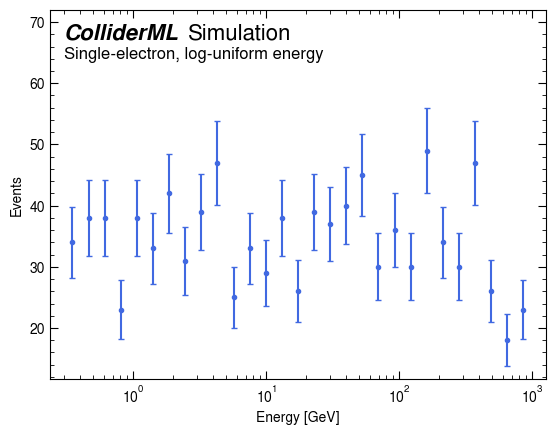

In [ ]:
fig, ax = plt.subplots()
energy_data = generator_electrons["energy"]
log_bins = np.logspace(np.log10(energy_data.min()), np.log10(energy_data.max()), 30)
counts, bins = np.histogram(energy_data, bins=log_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Events')
ax.set_xscale('log')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-electron, log-uniform energy")

In [ ]:
calo_digi_sum = calo_digi_hits.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")

In [ ]:
# merge the generator electrons with the calo digi sum
combined_electrons = generator_electrons.merge(calo_digi_sum, left_on="event_id", right_on="event_id", how="inner")
combined_electrons

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum
0,2,1,11,33554432,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.532331,1.531820,1,False,9,1,True,0.036311
1,4,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.316518,0.316007,1,False,10,81,True,0.247788
2,5,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.392895,0.392384,1,False,13,115,True,0.411645
3,6,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.343148,0.342637,1,False,13,26,True,0.311164
4,7,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.170465,1.169954,1,False,14,236,True,1.249798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,995,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,46.359856,46.359345,1,False,11,675,True,43.910133
948,996,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,46.401099,46.400588,1,False,12,607,True,45.859158
949,997,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,31.481206,31.480695,1,False,15,95,True,31.820776
950,998,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.083552,1.083041,1,False,14,85,True,0.453685


In [ ]:
def calculate_eta(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log((p + pz) / (p - pz))

combined_electrons["eta"] = calculate_eta(combined_electrons["px"], combined_electrons["py"], combined_electrons["pz"])
combined_electrons["pt"] = np.sqrt(combined_electrons["px"]**2 + combined_electrons["py"]**2)
combined_electrons

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum,eta,pt
0,2,1,11,33554432,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.532331,1.531820,1,False,9,1,True,0.036311,-3.402071,0.101953
1,4,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.316518,0.316007,1,False,10,81,True,0.247788,-2.353778,0.059606
2,5,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.392895,0.392384,1,False,13,115,True,0.411645,1.307977,0.197979
3,6,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.343148,0.342637,1,False,13,26,True,0.311164,0.590723,0.290899
4,7,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.170465,1.169954,1,False,14,236,True,1.249798,0.264651,1.130638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,995,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,46.359856,46.359345,1,False,11,675,True,43.910133,1.186314,25.896958
948,996,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,46.401099,46.400588,1,False,12,607,True,45.859158,-2.767541,5.806579
949,997,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,31.481206,31.480695,1,False,15,95,True,31.820776,2.078250,7.758175
950,998,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.083552,1.083041,1,False,14,85,True,0.453685,-1.006060,0.698962


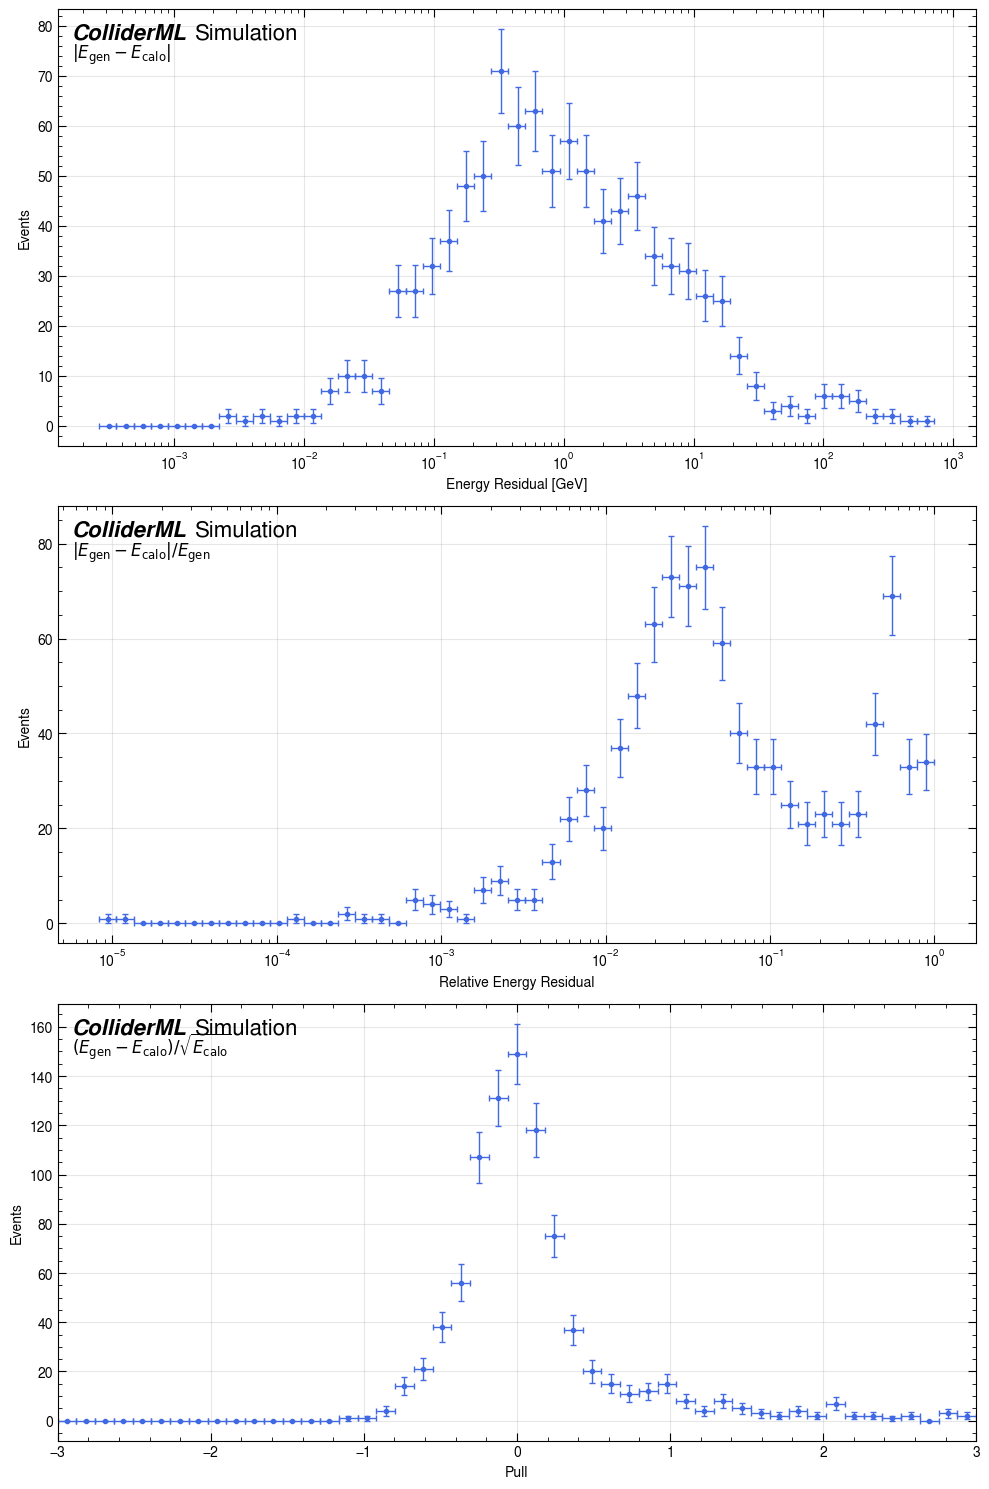

In [ ]:
residual = (combined_electrons["energy"] - combined_electrons["energy_sum"]).abs()
relative_residual = residual / combined_electrons["energy"]
pull = (combined_electrons["energy"] - combined_electrons["energy_sum"]) / np.sqrt(combined_electrons["energy_sum"])
# Set pull to 0 where energy_sum is 0
pull[combined_electrons["energy_sum"] == 0] = 0

# Create high-quality ATLAS-style plot with error bars
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Absolute residual with log x-axis
bins_residual = np.logspace(np.log10(residual[residual > 0].min()), np.log10(residual.max()), 50)
counts, bins = np.histogram(residual, bins=bins_residual)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[0].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[0].set_xlabel('Energy Residual [GeV]')
ax[0].set_ylabel('Events')
ax[0].set_xscale('log')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}|$", axes=ax[0], enlarge=1.0)

# Plot 2: Relative residual with log x-axis
bins_relative = np.logspace(np.log10(relative_residual[relative_residual > 0].min()), 
                             np.log10(relative_residual.max()), 50)
counts, bins = np.histogram(relative_residual, bins=bins_relative)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[1].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[1].set_xlabel('Relative Energy Residual')
ax[1].set_ylabel('Events')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$", axes=ax[1], enlarge=1.0)

# Plot 3: Pull distribution (linear x-axis is more appropriate for pulls)
bins_pull = np.linspace(-3, 3, 50)
counts, bins = np.histogram(pull, bins=bins_pull)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[2].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[2].set_xlabel('Pull')
ax[2].set_ylabel('Events')
# Set x-axis limits to -3 to 3
ax[2].set_xlim(-3, 3)
ax[2].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$(E_{\mathrm{gen}} - E_{\mathrm{calo}}) / \sqrt{E_{\mathrm{calo}}}$", axes=ax[2], enlarge=1.0)

plt.tight_layout()

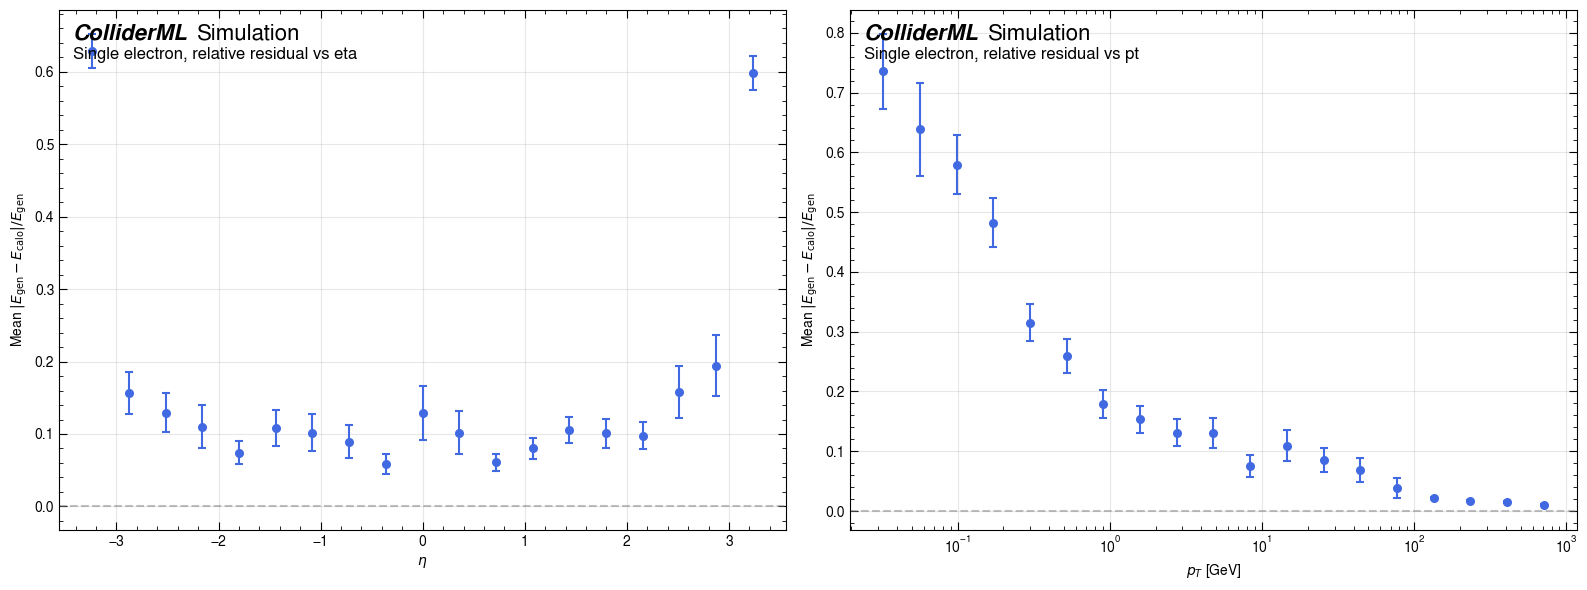

In [ ]:
# Profile plots: Mean relative residual vs eta and pt
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Profile 1: Mean relative residual vs eta
eta_bins = np.linspace(combined_electrons['eta'].min(), combined_electrons['eta'].max(), 20)
eta_bin_centers = []
eta_bin_widths = []
eta_mean_residuals = []
eta_errors = []

for i in range(len(eta_bins)-1):
    mask = (combined_electrons['eta'] >= eta_bins[i]) & (combined_electrons['eta'] < eta_bins[i+1])
    if mask.sum() > 0:
        eta_bin_centers.append((eta_bins[i] + eta_bins[i+1]) / 2)
        eta_bin_widths.append(eta_bins[i+1] - eta_bins[i])
        residuals_in_bin = relative_residual[mask]
        eta_mean_residuals.append(residuals_in_bin.mean())
        eta_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[0].errorbar(eta_bin_centers, eta_mean_residuals, xerr=eta_bin_widths/2, yerr=eta_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[0].set_xlabel(r'$\eta$')
ax[0].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs eta", axes=ax[0], enlarge=1.0)

# Profile 2: Mean relative residual vs pt (log scale)
pt_bins = np.logspace(np.log10(combined_electrons['pt'].min()), 
                       np.log10(combined_electrons['pt'].max()), 20)
pt_bin_centers = []
pt_bin_widths = []
pt_mean_residuals = []
pt_errors = []

for i in range(len(pt_bins)-1):
    mask = (combined_electrons['pt'] >= pt_bins[i]) & (combined_electrons['pt'] < pt_bins[i+1])
    if mask.sum() > 0:
        # Use geometric mean for bin center in log space
        pt_bin_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))
        pt_bin_widths.append(pt_bins[i+1] - pt_bins[i])
        residuals_in_bin = relative_residual[mask]
        pt_mean_residuals.append(residuals_in_bin.mean())
        pt_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[1].errorbar(pt_bin_centers, pt_mean_residuals, xerr=pt_bin_widths/2, yerr=pt_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[1].set_xlabel(r'$p_T$ [GeV]')
ax[1].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs pt", axes=ax[1], enlarge=1.0)

plt.tight_layout()

## Pion Sample

In [19]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion_loguniform/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 1000), full_load=False, detector_params=detector_params)

In [20]:
tracker_hits = batch.get_tracker_hits_df()
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
particles = batch.get_particles_df()
print(f"""
Unique events IDs in particles: {particles.event_id.unique()}
Length of particles: {len(particles)}
Length of tracker_hits: {len(tracker_hits)}
Length of calo_hits: {len(calo_hits)}
Length of calo_contributions: {len(calo_contributions)}
Events with non-empty calo_hits: {len(calo_hits.event_id.unique())}
""")

Augmenting particle hit counts with tracker hits

Unique events IDs in particles: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 2

In [21]:
calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion_loguniform/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 1000), full_load=False, detector_params=detector_params)

In [22]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
print(f"""
Unique events IDs in particles: {particles.event_id.unique()}
Length of particles: {len(particles)}
Length of calo_tracker_hits: {len(calo_tracker_hits)}
Length of calo_truth_hits: {len(calo_truth_hits)}
Length of calo_digi_contributions: {len(calo_digi_contributions)}
Length of calo_digi_hits: {len(calo_digi_hits)}
Events with non-empty calo_digi_hits: {len(calo_digi_hits.event_id.unique())}
""")

Augmenting particle hit counts with tracker hits

Unique events IDs in particles: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 2

In [23]:
print(f"Loaded {len(calo_digi_hits)} digitized calo hits")
print(f"\nColumns: {list(calo_digi_hits.columns)}")
print(f"\nDetectors: {calo_digi_hits['detector'].unique()}")
print(f"\nFirst few rows:")
print(calo_digi_hits.head())

# Verify all expected columns are present
expected_cols = ['cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 
                 'detector', 'r', 'R', 'phi', 'theta', 'eta', 'event_id']
missing_cols = set(expected_cols) - set(calo_digi_hits.columns)
if missing_cols:
    print(f"\nWARNING: Missing columns: {missing_cols}")
else:
    print(f"\n✓ All expected columns present")


Loaded 1039906 digitized calo hits

Columns: ['event_id', 'subentry', 'cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 'detector', 'r', 'R', 'phi', 'theta', 'eta']

Detectors: ['digiECalBarrelCollection' 'digiECalEndcapCollection'
 'digiHCalBarrelCollection' 'digiHCalEndcapCollection']

First few rows:
   event_id  subentry                cellID    energy  energy_error      time  \
0        10         0  18437736956076060688  0.031189           0.0  9.831927   
1        10         1  18437736951781158928  0.028945           0.0  9.864887   
2        10         2  18437455472509546512  0.041674           0.0  9.899879   
3        10         3  18437455472509612048  0.091795           0.0  9.951061   
4        14         0  18444210927785017360  0.082686           0.0  1.896390   

             x           y           z   type                  detector  \
0  1252.400024   96.900002 -163.199997  11010  digiECalBarrelCollection   
1  1257.449951   91.800003 -163.199997  2

In [ ]:
high_energy_events = calo_digi_hits[calo_digi_hits["energy"] > 10].event_id.unique()
print(f"Number of high energy events: {len(high_energy_events)}")
high_energy_event = high_energy_events[0]
print(f"High energy event: {high_energy_event}")

Number of high energy events: 72
High energy event: 751


In [41]:
sample_calo_digi_hits = calo_digi_hits[calo_digi_hits["event_id"] == high_energy_event]
sample_calo_particles = calo_particles[calo_particles["event_id"] == high_energy_event]

In [45]:
sample_calo_digi_hits.energy.sum()

np.float32(809.00073)

In [44]:
sample_calo_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker
192339,751,0,0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0.000000,0.000000,0.000000,0,False,0,0,True
192340,751,1,-211,16777216,-1.0,0.000000,0.139570,0.000000,0.000000,0.000000,...,0,1,0.000000,950.741233,950.601663,1,False,14,2091,True
192341,751,2,-3312,1157627904,1.0,9.179553,1.321710,1141.880093,-365.818019,2477.009150,...,1,2,1199.046692,112.119108,110.797398,2,True,0,1099,False
192342,751,3,211,1157627904,1.0,9.179553,0.139570,1141.880093,-365.818019,2477.009150,...,2,3,1199.046692,1.353937,1.214367,3,True,0,88,False
192343,751,4,211,1157627904,1.0,9.179553,0.139570,1141.880093,-365.818019,2477.009150,...,3,4,1199.046692,1.587697,1.448127,4,True,0,387,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195523,751,3184,-11,1426063360,1.0,13.707268,0.000511,1709.562679,-554.269394,3695.385369,...,3183,3184,1797.169751,0.240718,0.240207,3184,True,0,6,False
195524,751,3185,11,1426063360,-1.0,13.559847,0.000511,1691.113367,-548.422727,3655.652636,...,3184,3185,1777.816612,0.412599,0.412088,3185,True,0,48,False
195525,751,3186,-11,1426063360,1.0,13.559847,0.000511,1691.113367,-548.422727,3655.652636,...,3185,3186,1777.816612,0.639157,0.638646,3186,True,0,12,False
195526,751,3187,-11,1426063360,1.0,13.819798,0.000511,1722.894267,-564.567342,3724.917616,...,3186,3187,1813.036387,0.106698,0.106187,3187,True,0,15,False


In [42]:
sample_calo_particles.iloc[1][["PDG", "vx", "vy", "vz", "px", "py", "pz", "energy"]]

PDG             -211
vx               0.0
vy               0.0
vz               0.0
px        394.329896
py       -126.900731
pz        855.750554
energy    950.741233
Name: 192340, dtype: object

In [25]:
calo_digi_contributions

,event_id,subentry,energy,time,particle_id,detector
0,8,0,1.819416e-05,232.720306,1,ECalBarrelCollection
1,8,1,2.846446e-05,235.350845,1,ECalBarrelCollection
2,8,2,3.433625e-06,684.434998,1,ECalBarrelCollection
3,8,3,3.933293e-06,191.261856,1,ECalBarrelCollection
4,8,4,4.063974e-05,895.501282,1,ECalBarrelCollection
...,...,...,...,...,...,...
17806291,999,2941,1.513599e-08,487.596893,137,HCalEndcapCollection
17806292,999,2942,6.483030e-09,548.165466,137,HCalEndcapCollection
17806293,999,2943,1.973040e-10,4988.943359,137,HCalEndcapCollection
17806294,999,2944,3.003570e-10,5005.575195,137,HCalEndcapCollection


In [26]:
calo_truth_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,8,0,121878729357352976,1.819416e-05,845.770447,953.957764,2208.300049,0,1,ECalBarrelCollection,1274.897217,2549.892578,0.845439,0.523577,1.317002
1,8,1,121597254380838928,2.846446e-05,856.483093,964.670410,2203.199951,1,2,ECalBarrelCollection,1290.020264,2553.084717,0.844734,0.529705,1.304809
2,8,2,133700412091072528,3.433625e-06,723.228821,-1062.215820,2417.399902,2,3,ECalBarrelCollection,1285.053467,2737.733643,-0.973026,0.488595,1.389193
3,8,3,164099726756675600,3.933293e-06,791.217163,-1101.354126,2968.199951,3,4,ECalBarrelCollection,1356.099365,3263.313721,-0.947825,0.428557,1.525007
4,8,4,42502923364075536,8.913016e-04,714.254517,-1097.996704,770.099976,4,21,ECalBarrelCollection,1309.868774,1519.476929,-0.994065,1.039305,0.558440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2886732,999,1139,18437455425260622100,4.426663e-05,180.000000,-872.489136,3698.500000,2936,2937,HCalEndcapCollection,890.863220,3804.279053,-1.367344,0.236369,2.130838
2886733,999,1140,18437455420965654804,6.502566e-05,150.000000,-872.489136,3698.500000,2937,2939,HCalEndcapCollection,885.289368,3802.977539,-1.400539,0.234944,2.136941
2886734,999,1141,18438862800144306452,1.853965e-07,180.000000,-1022.489136,3800.500000,2939,2943,HCalEndcapCollection,1038.211914,3939.756836,-1.396541,0.266671,2.008935
2886735,999,1142,18439425694263150868,4.976610e-10,208.755447,-1052.736694,3800.500000,2943,2945,HCalEndcapCollection,1073.234985,3949.130615,-1.375038,0.275226,1.976968


In [27]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,10,0,18437736956076060688,0.031189,0.0,9.831927,1.252400e+03,96.900002,-163.199997,11010,digiECalBarrelCollection,1256.143066,1266.700317,0.077218,1.699994,-0.129559
1,10,1,18437736951781158928,0.028945,0.0,9.864887,1.257450e+03,91.800003,-163.199997,21010,digiECalBarrelCollection,1260.796387,1271.315063,0.072876,1.699522,-0.129083
2,10,2,18437455472509546512,0.041674,0.0,9.899879,1.262500e+03,86.699997,-168.300003,31010,digiECalBarrelCollection,1265.473511,1276.615845,0.068566,1.703014,-0.132605
3,10,3,18437455472509612048,0.091795,0.0,9.951061,1.267550e+03,86.699997,-168.300003,41010,digiECalBarrelCollection,1270.511719,1281.610229,0.068293,1.702496,-0.132082
4,14,0,18444210927785017360,0.082686,0.0,1.896390,9.937679e+02,-777.393188,-45.900002,11010,digiECalBarrelCollection,1261.711060,1262.545654,-0.663835,1.607159,-0.036371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039901,999,149,18439144236466245908,0.023628,0.0,0.183852,-9.000000e+01,-1022.489136,3749.500000,32021,digiHCalEndcapCollection,1026.442383,3887.458496,-1.658591,0.267208,2.006901
1039902,999,150,18439425715738054932,0.268014,0.0,0.943082,-6.000000e+01,-1052.489136,3851.500000,52021,digiHCalEndcapCollection,1054.197998,3993.167236,-1.627742,0.267167,2.007054
1039903,999,151,18439425720033022228,0.018210,0.0,8.642816,-3.000000e+01,-1052.489136,3851.500000,52021,digiHCalEndcapCollection,1052.916626,3992.829102,-1.599292,0.266858,2.008227
1039904,999,152,18441396036280193300,0.046947,0.0,4.065157,-9.000000e+01,-1262.489136,3953.500000,72021,digiHCalEndcapCollection,1265.692993,4151.161133,-1.641964,0.309834,1.856820


In [30]:
generator_pions = calo_particles[(calo_particles["PDG"] == -211) & (calo_particles["created_in_simulation"] == False)]

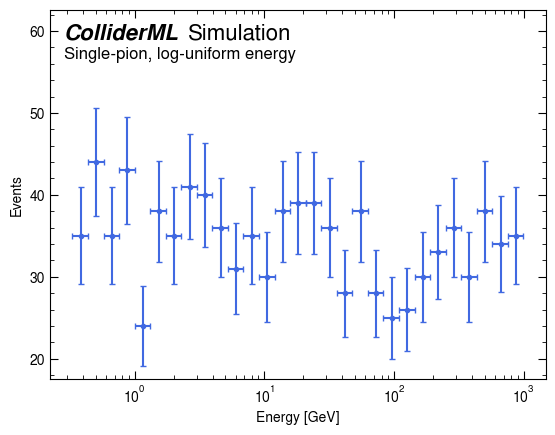

In [31]:
fig, ax = plt.subplots()
energy_data = generator_pions["energy"]
log_bins = np.logspace(np.log10(energy_data.min()), np.log10(energy_data.max()), 30)
counts, bins = np.histogram(energy_data, bins=log_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Events')
ax.set_xscale('log')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-pion, log-uniform energy")

In [32]:
calo_digi_sum = calo_digi_hits.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")

In [33]:
# merge the generator pions with the calo digi sum
combined_pions = generator_pions.merge(calo_digi_sum, left_on="event_id", right_on="event_id", how="inner")
combined_pions

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum
0,2,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,0.369432,0.229862,1,False,9,69,True,0.155102
1,4,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,0.406686,0.267116,1,False,7,54,True,0.095584
2,5,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,0.521688,0.382117,1,False,10,62,True,0.217741
3,6,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,0.389603,0.250033,1,False,9,0,True,0.062672
4,7,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,6.479094,6.339524,1,False,15,423,True,1.998335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,995,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,832.593736,832.454166,1,False,14,811,True,718.099243
926,996,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,380.910997,380.771427,1,False,15,908,True,195.689468
927,997,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,890.842571,890.703000,1,False,17,818,True,791.463867
928,998,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,1,0.0,800.444351,800.304780,1,False,14,401,True,409.426880


In [34]:
def calculate_eta(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log((p + pz) / (p - pz))

combined_pions["eta"] = calculate_eta(combined_pions["px"], combined_pions["py"], combined_pions["pz"])
combined_pions["pt"] = np.sqrt(combined_pions["px"]**2 + combined_pions["py"]**2)
combined_pions

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum,eta,pt
0,2,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.369432,0.229862,1,False,9,69,True,0.155102,-2.710412,0.045299
1,4,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.406686,0.267116,1,False,7,54,True,0.095584,2.108226,0.091438
2,5,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.521688,0.382117,1,False,10,62,True,0.217741,1.745857,0.170244
3,6,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.389603,0.250033,1,False,9,0,True,0.062672,-2.368190,0.067537
4,7,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,6.479094,6.339524,1,False,15,423,True,1.998335,-2.678114,0.885745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,995,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,832.593736,832.454166,1,False,14,811,True,718.099243,-0.184990,818.547871
926,996,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,380.910997,380.771427,1,False,15,908,True,195.689468,2.350596,71.957315
927,997,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,890.842571,890.703000,1,False,17,818,True,791.463867,-0.365697,834.422435
928,998,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,800.444351,800.304780,1,False,14,401,True,409.426880,-3.058168,75.034075


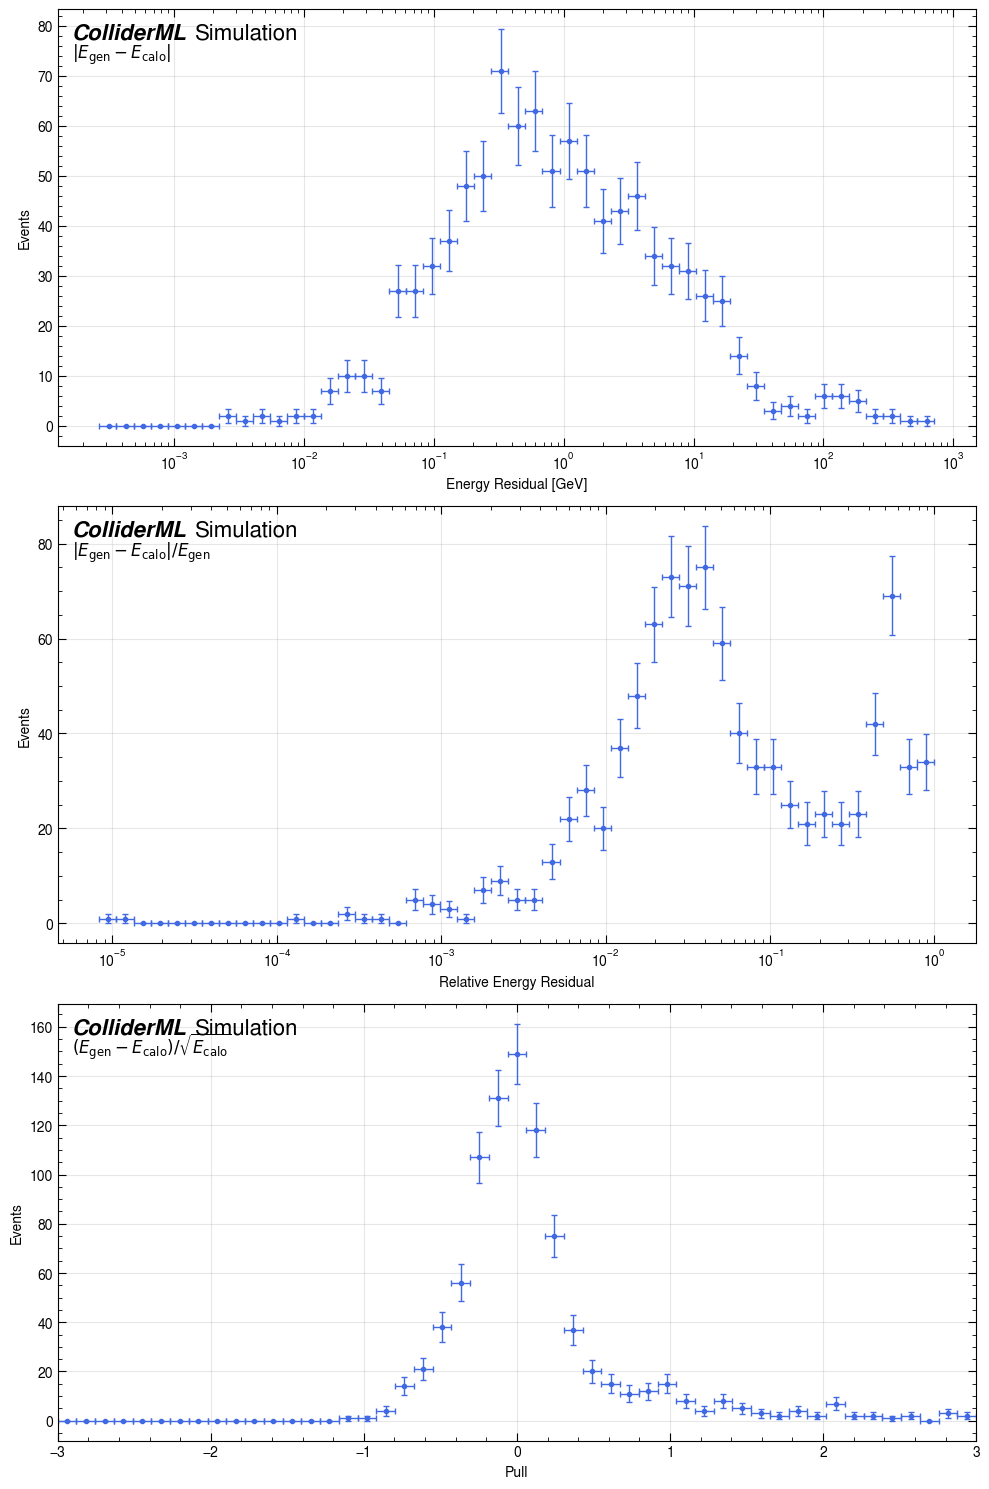

In [ ]:
residual = (combined_electrons["energy"] - combined_electrons["energy_sum"]).abs()
relative_residual = residual / combined_electrons["energy"]
pull = (combined_electrons["energy"] - combined_electrons["energy_sum"]) / np.sqrt(combined_electrons["energy_sum"])
# Set pull to 0 where energy_sum is 0
pull[combined_electrons["energy_sum"] == 0] = 0

# Create high-quality ATLAS-style plot with error bars
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Absolute residual with log x-axis
bins_residual = np.logspace(np.log10(residual[residual > 0].min()), np.log10(residual.max()), 50)
counts, bins = np.histogram(residual, bins=bins_residual)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[0].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[0].set_xlabel('Energy Residual [GeV]')
ax[0].set_ylabel('Events')
ax[0].set_xscale('log')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}|$", axes=ax[0], enlarge=1.0)

# Plot 2: Relative residual with log x-axis
bins_relative = np.logspace(np.log10(relative_residual[relative_residual > 0].min()), 
                             np.log10(relative_residual.max()), 50)
counts, bins = np.histogram(relative_residual, bins=bins_relative)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[1].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[1].set_xlabel('Relative Energy Residual')
ax[1].set_ylabel('Events')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$", axes=ax[1], enlarge=1.0)

# Plot 3: Pull distribution (linear x-axis is more appropriate for pulls)
bins_pull = np.linspace(-3, 3, 50)
counts, bins = np.histogram(pull, bins=bins_pull)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[2].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[2].set_xlabel('Pull')
ax[2].set_ylabel('Events')
# Set x-axis limits to -3 to 3
ax[2].set_xlim(-3, 3)
ax[2].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$(E_{\mathrm{gen}} - E_{\mathrm{calo}}) / \sqrt{E_{\mathrm{calo}}}$", axes=ax[2], enlarge=1.0)

plt.tight_layout()

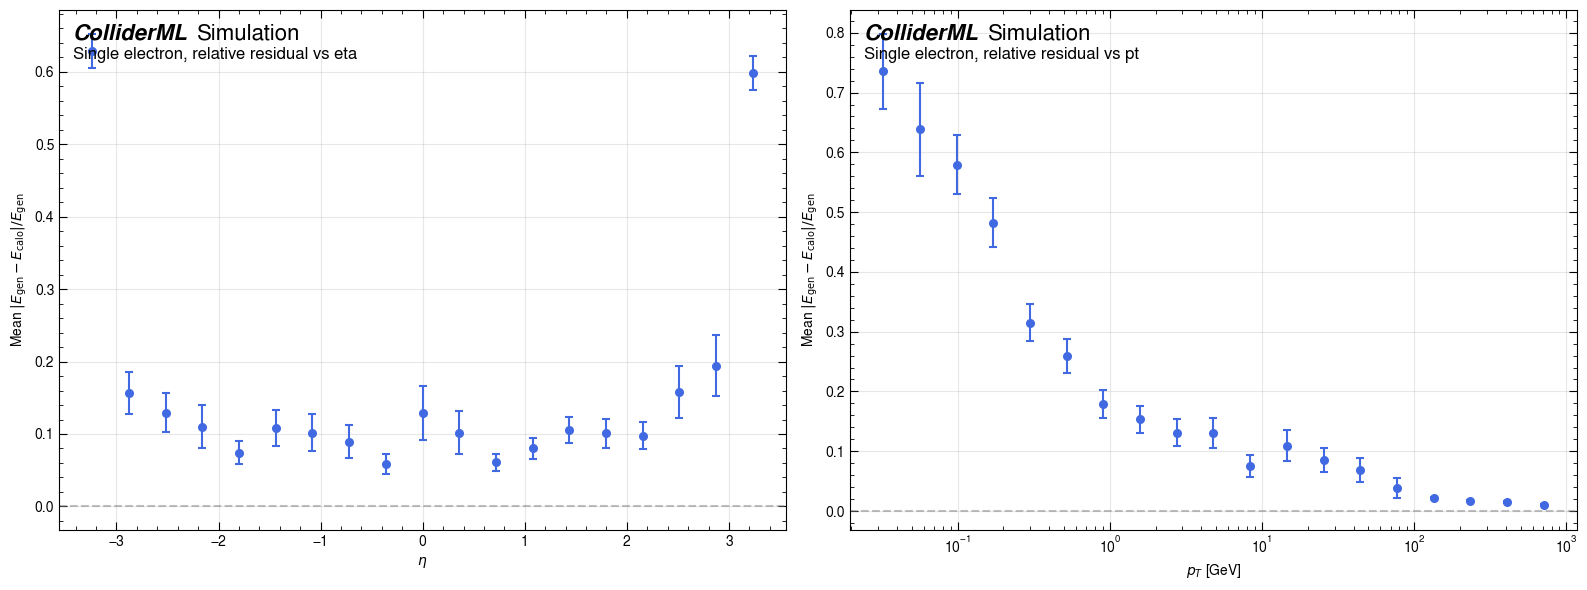

In [ ]:
# Profile plots: Mean relative residual vs eta and pt
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Profile 1: Mean relative residual vs eta
eta_bins = np.linspace(combined_electrons['eta'].min(), combined_electrons['eta'].max(), 20)
eta_bin_centers = []
eta_bin_widths = []
eta_mean_residuals = []
eta_errors = []

for i in range(len(eta_bins)-1):
    mask = (combined_electrons['eta'] >= eta_bins[i]) & (combined_electrons['eta'] < eta_bins[i+1])
    if mask.sum() > 0:
        eta_bin_centers.append((eta_bins[i] + eta_bins[i+1]) / 2)
        eta_bin_widths.append(eta_bins[i+1] - eta_bins[i])
        residuals_in_bin = relative_residual[mask]
        eta_mean_residuals.append(residuals_in_bin.mean())
        eta_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[0].errorbar(eta_bin_centers, eta_mean_residuals, xerr=eta_bin_widths/2, yerr=eta_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[0].set_xlabel(r'$\eta$')
ax[0].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs eta", axes=ax[0], enlarge=1.0)

# Profile 2: Mean relative residual vs pt (log scale)
pt_bins = np.logspace(np.log10(combined_electrons['pt'].min()), 
                       np.log10(combined_electrons['pt'].max()), 20)
pt_bin_centers = []
pt_bin_widths = []
pt_mean_residuals = []
pt_errors = []

for i in range(len(pt_bins)-1):
    mask = (combined_electrons['pt'] >= pt_bins[i]) & (combined_electrons['pt'] < pt_bins[i+1])
    if mask.sum() > 0:
        # Use geometric mean for bin center in log space
        pt_bin_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))
        pt_bin_widths.append(pt_bins[i+1] - pt_bins[i])
        residuals_in_bin = relative_residual[mask]
        pt_mean_residuals.append(residuals_in_bin.mean())
        pt_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[1].errorbar(pt_bin_centers, pt_mean_residuals, xerr=pt_bin_widths/2, yerr=pt_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[1].set_xlabel(r'$p_T$ [GeV]')
ax[1].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs pt", axes=ax[1], enlarge=1.0)

plt.tight_layout()